# Waste Recycling Point (WRP) Simulation Execution
This notebook imports the discrete event simulation framework, establishes the specific WRP topology, executes the simulation loop, and extracts actionable metrics from the ledger.

In [11]:
from DSE import DSEEnvironment, Ledger
from Sampler import Sampler
from Enums import WasteType, VehicleSize
from WRP_Blocks import WRPGeneratorBlock, WRPZoneBlock, JunctionBlock, DestroyerBlock

env = DSEEnvironment()
ledger = Ledger()

# --- 1. Diverse Distributions (Configured for Seconds) ---
# Gamma creates dense clusters of arrivals
arrival_sampler = Sampler("gamma", {"shape": 2.0, "scale": 15.0}) 
entrance_sampler = Sampler("lognormal", {"mean": 2.5, "sigma": 0.5}) # ~12-15s

# Service times in seconds
hall_sampler = Sampler("triangular", {"left": 300.0, "mode": 600.0, "right": 900.0})
overflow_sampler = Sampler("normal", {"loc": 400.0, "scale": 50.0})
green_sampler = Sampler("exponential", {"scale": 200.0})
rest_sampler = Sampler("exponential", {"scale": 250.0})
dcdd_sampler = Sampler("exponential", {"scale": 300.0})

# --- 2. Advanced Routing Functions ---
def main_routing(entity, next_blocks):
    b_map = {b.name: b for b in next_blocks}
    if WasteType.TYPE_A in entity.waste_types: return b_map["Green"]
    # All Type B vehicles must now pass through the Hall route
    if WasteType.TYPE_B in entity.waste_types: return b_map["Hall"]
    if WasteType.TYPE_REST in entity.waste_types: return b_map["Rest"]
    return b_map["Exit"]

def post_hall_routing(entity, next_blocks):
    b_map = {b.name: b for b in next_blocks}
    # Check the flag set by the bypass logic
    if entity.flags.get('bypassed_Hall'): return b_map["Overflow"]
    if WasteType.TYPE_DCDD in entity.waste_types: return b_map["DcDd"]
    if WasteType.TYPE_REST in entity.waste_types: return b_map["Rest"]
    return b_map["Exit"]

# --- 3. Block Instantiation ---
generator = WRPGeneratorBlock(env, "Arrival_Gen", ledger, arrival_sampler, log=True)
entrance = WRPZoneBlock(env, "Entrance", ledger, 1, float('inf'), entrance_sampler)
main_junction = JunctionBlock(env, "Main_Junction", ledger, routing_func=main_routing)

# Initialize overflow first so Hall can check its capacity for the bypass logic
overflow = WRPZoneBlock(env, "Overflow", ledger, 10, 0, overflow_sampler)

def hall_bypass_logic(entity):
    # A7: Small vehicles bypass Hall to go to Overflow IF Overflow is not full
    if entity.vehicle_size == VehicleSize.SMALL and WasteType.TYPE_B in entity.waste_types:
        return overflow.can_receive(entity)
    return False

hall = WRPZoneBlock(env, "Hall", ledger, 12, 14, hall_sampler, bypass_func=hall_bypass_logic)
post_hall_junction = JunctionBlock(env, "Post_Hall_Junction", ledger, routing_func=post_hall_routing)

green = WRPZoneBlock(env, "Green", ledger, 5, 0, green_sampler)
dcdd = WRPZoneBlock(env, "DcDd", ledger, 7, 0, dcdd_sampler)
rest = WRPZoneBlock(env, "Rest", ledger, 5, 0, rest_sampler)
exit_node = DestroyerBlock(env, "Exit", ledger)

# --- 4. Connect the Network ---
generator.connect(entrance)
entrance.connect(main_junction)

# Main splits to Green, Hall, Rest, or Exit
main_junction.connect(green)
main_junction.connect(hall)
main_junction.connect(rest)
main_junction.connect(exit_node)

# Hall connects to Post_Hall_Junction
hall.connect(post_hall_junction)

# Post Hall splits to Overflow, DcDd, Rest, or Exit
post_hall_junction.connect(overflow)
post_hall_junction.connect(dcdd)
post_hall_junction.connect(rest)
post_hall_junction.connect(exit_node)

# Finalize downstream connections
overflow.connect(dcdd)
overflow.connect(rest)
overflow.connect(exit_node)
green.connect(rest)
green.connect(exit_node)
dcdd.connect(rest)
dcdd.connect(exit_node)
rest.connect(exit_node)

# --- 5. Execution ---
env.run(end_time=28800.0) # Run for 8 simulated hours (in seconds)



In [12]:
import pandas as pd
df = ledger.to_dataframe()

# Data Processing: Calculate Wait Times per Zone
df_received = df[df['event'] == 'ENTITY_RECEIVED'][['time', 'entity_id', 'block']].rename(columns={'time': 'time_received'})
df_started = df[df['event'] == 'SERVICE_STARTED'][['time', 'entity_id', 'block']].rename(columns={'time': 'time_started'})

wait_df = pd.merge(df_received, df_started, on=['entity_id', 'block'], how='inner')
wait_df['wait_time'] = wait_df['time_started'] - wait_df['time_received']

wait_summary = wait_df.groupby('block')['wait_time'].describe()
display(wait_summary)

,count,mean,std,min,25%,50%,75%,max
block,,,,,,,,
Entrance,3.0,0.594876,1.030356,0.0,0.0,0.0,0.892314,1.784628
Hall,2.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000


In [13]:
df

,time,entity_id,entity_type,block,event
0,0.000000,0,CUSTOMER,Arrival_Gen,ENTITY_CREATED
1,0.000000,0,CUSTOMER,Entrance,ENTITY_RECEIVED
2,0.000000,0,CUSTOMER,Entrance,SERVICE_STARTED
3,7.819917,1,CUSTOMER,Arrival_Gen,ENTITY_CREATED
4,7.819917,1,CUSTOMER,Entrance,ENTITY_RECEIVED
...,...,...,...,...,...
1917,28674.455179,948,CUSTOMER,Entrance,ENTITY_RECEIVED
1918,28734.834214,949,CUSTOMER,Arrival_Gen,ENTITY_CREATED
1919,28734.834214,949,CUSTOMER,Entrance,ENTITY_RECEIVED
1920,28774.021319,950,CUSTOMER,Arrival_Gen,ENTITY_CREATED


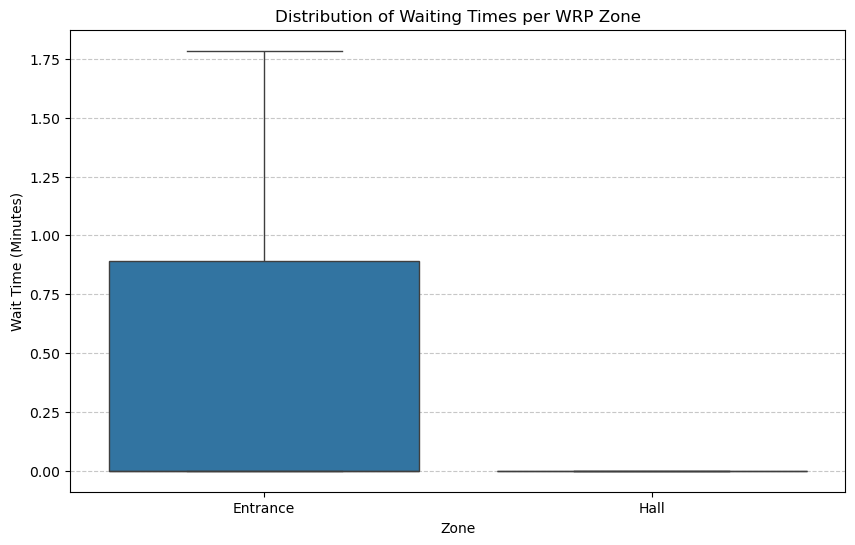

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization: Wait Time Distributions by Zone
plt.figure(figsize=(10, 6))
sns.boxplot(data=wait_df, x='block', y='wait_time')
plt.title('Distribution of Waiting Times per WRP Zone')
plt.ylabel('Wait Time (Minutes)')
plt.xlabel('Zone')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [15]:
import json
import pandas as pd

def export_ledger_for_visualization(ledger_df, filepath="wrp_vis_data.json"):
    """
    Transforms a flat discrete-event ledger into a keyframe sequence per entity.
    """
    # Ensure sequential processing
    df = ledger_df.sort_values(by=['entity_id', 'time'])
    
    entities_data = {}
    
    for _, row in df.iterrows():
        eid = int(row['entity_id'])
        if eid not in entities_data:
            # Note: We extract vehicle size if it was logged, otherwise default to small
            entities_data[eid] = {
                "id": eid,
                "type": row['entity_type'],
                "sequence": []
            }
            
        # Standardize the state representation
        state = row['event']
        node = row['block']
        
        # Skip pure routing junctions as they possess no physical space or duration
        if state == 'ENTITY_ROUTED':
            continue
            
        entities_data[eid]["sequence"].append({
            "time": float(row['time']),
            "node": node,
            "state": state
        })
        
    # Filter out entities that have no meaningful sequence
    cleaned_data = {k: v for k, v in entities_data.items() if len(v['sequence']) > 1}
    
    payload = {
        "max_time": float(df['time'].max()),
        "entities": cleaned_data
    }
    
    with open(filepath, 'w') as f:
        json.dump(payload, f, indent=2)
        
    print(f"Exported visualization data for {len(cleaned_data)} entities to {filepath}")

export_ledger_for_visualization(df)

Exported visualization data for 951 entities to wrp_vis_data.json
